# Testing emcee_ensembler class and fitemcee function!

In the last notebook I took all the helper functions I have been making and configured them into methods for a emcee_ensembler class. 

That way, instead of the user having to keep track of up to 10 different variables, the methods simply update the attributes of the emcee_ensembler class until all the needed attributes for mcmc fitting are ready!

## The barest iteration of the emcee_ensembler is below. 

Things still needing implementation include:
- DOCSTRINGS EXPLAINING EACH METHOD OF THE PIPELINE ;-;
- An option to save the outputs of the emcee fitting (either thru a csv like ucdmcmc already does OR save the hd5 file emcee creates)
- Implement (or emulate) the plotting methods from ucdmcmc
- Flags for if a method is called out of order (assuming someone is not using fitemcee and manually using the emcee_ensembler class)
- Flags for likely issues / their fixes
- lots of kwargs for flexibility 

I also have not tested EVERY model in ucdmcmc... just some. If you are reading this, are testing out my emcee_ensembler, and run into any kind of error or bugs PLEASE let me know!!!!!

In [3]:
import ucdmcmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import itertools
import astropy.units as u
import emcee
import scipy.interpolate
import corner
import copy


# fitgrid is from ucdmcmc but I had to fix some variable names in it for it to work as intended
def fitGrid(spc,models,altpar={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='parameters',absolute=False,
	report=True,xscale='linear',yscale='linear',file_prefix='gridfit_',verbose=ucdmcmc.ERROR_CHECKING):
	'''
	Purpose
	-------

	Fit a spectrum to model grid, with optional constraints. This function uses a chi-square statistic and determines the
	overall best fit model from a set of model fluxes. 

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'parameters' : str
		Specify what the program should return; options are:
			* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
			* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
			* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
				and degrees of freedom added

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	report = True : bool
		Set to True to save an output file showing the best fit model

	file_prefix = 'gridfit_' : str
		Prefix to append to output file if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
		* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
		* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
			and degrees of freedom added

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('elfowl24','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=True)

	Best fit model:
		model = elfowl24
		co = 0.5
		kzz = 2.0
		logg = 5.0
		teff = 1000.0
		z = -0.0
		scale = 1.387711853929069e-24
		chi = 956.6257633740316
		radius = 0.0005224902503080241
		dof = 850.0
		rchi = 1.1254420745576843
		reduced chi2 = 1.1254420745576843

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
				par = list(set(list(mdls[k]))) # Changed dp --> mdls to properly mask for specific discrete parameters
				if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
				for p in par:
					if p not in plimits[k]: mdls = mdls[mdls[k]!=p]
				mdls.reset_index(inplace=True,drop=True)

			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	
# run through each grid point
	for x in ['scale','chis','radius','dof']: mdls[x] = [np.nan]*len(mdls)
	for jjj in range(len(mdls)):
		if len(altpar)>0:
			mdln = ucdmcmc.Spectrum(wave=spscl.wave,flux=np.array(mdls.loc[jjj,flux_name])*spscl.flux.unit)
			mdln.applyPar(altpar)
			mdlind = mdln.flux.value
		else: mdlind = np.array(mdls.loc[jjj,flux_name])
		chi,scl,dof = ucdmcmc.compareSpec(spscl.flux.value,mdlind,spscl.noise.value,verbose=verbose)
		mdls.loc[jjj,'chis'] = chi
		mdls.loc[jjj,'scale'] = scl
		mdls.loc[jjj,'dof'] = dof
# radius scaling assuming spectrum is in absolute flux units
		mdls.loc[jjj,'radius'] = (10.*u.pc*(scl**0.5)).to(u.Rsun).value
#	mdls['model'] = [mset]*len(mdls)

# best fit
	mpar = dict(mdls.loc[np.argmin(mdls['chis']),:])
	mpar['rchi'] = mpar['chis']/mpar['dof']
	dpars = list(mdls.keys())
	for x in [flux_name,'file']:
		if x in list(mpar.keys()): del mpar[x]
	if verbose==True or report==True: 
		print('\nBest parameters:')
		for k in mpar: print('\t{} = {}'.format(k,mpar[k]))
	comp = ucdmcmc.getGridModel(mdls,mpar,spscl.wave,verbose=verbose)
	if len(altpar)>0: 
		comp.applyPar(altpar)
		mpar = mpar | altpar
#	comp.scale(mpar['scale'])
#	comp = splat.Spectrum(wave=wave,flux=np.array(mdls.loc[ibest,flux_name])*mdls.loc[ibest,'scale']*spscl.flux.unit)
	diff = spscl.flux.value-comp.flux.value
#	dof = np.count_nonzero(~np.isnan(spscl.flux.value))-1
	# sclstd = np.nanstd(diff.flux.value,ddof=1)/np.nanmax(spscl.flux.value)
	# mpar['sclstd'] = sclstd

	if report == True:
# save parameters
		outfile = file_prefix+'_parameters.xlsx'
		mdls.drop(columns=[flux_name],inplace=True)
		mdls.to_excel(outfile,index=False)
# comparison plot		
		outfile = file_prefix+'_compare.pdf'
		label = '{} model '.format(mdls.loc[0,'model'])
		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(mpar['rchi'])
		label+='T={:.0f} '.format(mpar['teff'])
		label+='logg={:.2f} '.format(mpar['logg'])
		label+='z={:.2f} '.format(mpar['z'])
		ucdmcmc.plotCompare(spscl,comp,outfile=outfile,clabel=label,absolute=absolute,xscale=xscale,yscale=yscale)

	return mpar


class EMCEE_ensemble():
    """
    Class containing all the necessary attributes, methods, and formatting necessary for EMCEE fitting of ucdmcmc models.
    This class is structured for seamless use in the function, fitemcee()
    """
    def __init__(self, models, spectrum, N_WALKERS=24):
        """
        Read in a modelset and an 
        """
        # Attributes for initialization
        self.models = models
        self.spectrum = spectrum
        self.N_WALKERS = N_WALKERS
        self.FLUX_NAME = "flux"

        # Attributes for get_plimits()
        self.pfitc = None
        self.pfitd = None
        self.punknown = None
        self.plimits = None

        # Attributes for get_interp_grids
        self.interp_grid_dict = None
        self.interp_cols_dict = None
        self.interp_mask_dict = None

        # Attributes for get_bestfit_grid
        self.best_grid = None
        self.best_grid_key = None
        self.best_rchi = -np.inf

        # Attribute for get_ipar
        self.ipar = None

        # Attribute for ensemble_sampler
        self.EnsembleSampler = None

    def get_plimits(self): 

        if len(self.spectrum.flux) != len(self.models.loc[0, self.FLUX_NAME]):
            raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')

        mdls = copy.deepcopy(self.models)

        for non_param in ['file','model','scale','dof','rchi', "flux"]:
            try:
                mdls = mdls.drop(columns=non_param)
            except:
                continue

        pfitc = []
        pfitd = []
        punknown = []
        plimits = {}

        for col in list(mdls.columns):

            if pd.api.types.is_string_dtype(mdls[col]) or isinstance(mdls.loc[0,col],str):
                pfitd.append(col)
                plimits[col] = list(mdls[col].unique())

            elif mdls[col].dtype == np.float64 or isinstance(mdls.loc[0,col], float):
                pfitc.append(col)
                plimits[col] = [mdls[col].min(), mdls[col].max()]

            else:
                punknown.append(col)
                print(f"{col} was not recognized as contin or discrete.")
                print(f"dtype is {mdls[col].dtype}")
                print(f"object type is {type(mdls.loc[0, col])}")

            

        self.pfitc = pfitc
        self.pfitd = pfitd
        self.punknown = self.punknown
        self.plimits = plimits



    def get_emcee_grids(self):
        
        interp_grid_dict = {}
        interp_cols_dict = {}
        interp_mask_dict = {}

        combos = list(itertools.product(*(self.plimits[k] for k in self.pfitd))) or [()] # grrrrrr I didnt even know you can do that >:(
    
        for combo in combos:
            if combo:
                mask = np.logical_and.reduce([self.models[k] == v for k, v in zip(self.pfitd, combo)]) # I forgot zip existed O-O thats actually kinda smart
                sub = self.models[mask]
            else:
                sub = self.models

            pts = sub[self.pfitc].to_numpy()
            std_mask = sub[self.pfitc].std(axis=0).to_numpy() != 0
            active_cols = [c for c, keep in zip(self.pfitc, std_mask) if keep]

            try:
                interp_grid_dict[combo] = scipy.interpolate.LinearNDInterpolator(
                                                                        pts[:, std_mask], 
                                                                        np.stack(sub["flux"].to_numpy()), 
                                                                        rescale=True)
                
            except ValueError:
                interp_grid_dict[combo] = np.nan
                print(f"{combo} DOES NOT EXIST")
                
            interp_mask_dict[combo] = sub
            interp_cols_dict[combo] = active_cols          # keep the labels too
    
        
        self.interp_grid_dict = interp_grid_dict
        self.interp_cols_dict = interp_cols_dict
        self.interp_mask_dict = interp_mask_dict

    def get_best_grid(self):

        bestfit_grid = {}
        bestfit_grid_key = ()
        bestfit_rchi = np.inf
    
    
        for combo in self.interp_grid_dict.keys():
            combo_limits = dict(zip(list(self.pfitd), list(combo)))
    
            try: 
                gridfit_dict = fitGrid(self.spectrum, self.models, plimits=combo_limits)

            # except KeyError:
            except:
                print(f"{combo} IS A BROKEN GRID")
                continue
    
            if gridfit_dict["rchi"] < bestfit_rchi:
                bestfit_grid = gridfit_dict
                bestfit_grid_key = combo
                bestfit_rchi = gridfit_dict["rchi"]

        self.best_grid = bestfit_grid
        self.best_grid_key = bestfit_grid_key
        self.best_rchi = bestfit_rchi

    def get_ipar(self, key:tuple,
                *,
                initial_guess = False,
                max_iterations = 10000
                 ):

        p_lowers = []
        p_uppers = []
        p_random = []

        chosen_models = self.interp_mask_dict[key]

        for i, column in enumerate(self.interp_cols_dict[key]):

            if initial_guess:
                p_random.append(np.random.normal(initial_guess[column], 0.01, self.N_WALKERS))

            else:
                try:
                    # key_p_lower = self.interp_cols_dict[key][i].min()
                    # key_p_upper = self.interp_cols_dict[key][i].max()

                    key_p_lower = chosen_models[column].min()
                    key_p_upper = chosen_models[column].max()


                    p_lowers.append(key_p_lower)
                    p_uppers.append(key_p_upper)

                    p_random.append(np.random.uniform(key_p_lower, key_p_upper, self.N_WALKERS))

                except:
                    print(f"The data in the {column} column are strings?")
                    raise ValueError()

        ipar = np.array(p_random).T
        # print(ipar)
        for i in range(self.N_WALKERS):

            viable = False
            N_iterations = 0 

            while viable == False:

                if np.all(np.isfinite(self.interp_grid_dict[key](ipar[i, :]))):
                    viable = True

                elif not np.all(np.isfinite(self.interp_grid_dict[key](ipar[i, :]))):
                    if initial_guess:
                        # pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]]
                        ipar[i, :] = np.random.normal(pd.DataFrame([self.best_grid])[self.interp_cols_dict[self.best_grid_key]].to_numpy()[0,:], 0.01)

                    else:
                        ipar[i, :] = np.random.uniform(p_lowers, p_uppers)

                else:
                    print("NOT WORKING AS INTENDED")
                    break

                N_iterations += 1

                if N_iterations >= max_iterations:
                    raise RuntimeError(f"Resampled ipar {max_iterations} without viable map")

        self.ipar = ipar

    def log_L(self, theta, key):
    
            x = self.spectrum.wave.value
            y = self.spectrum.flux.value
            dy = self.spectrum.noise.value
    
            interpolator = self.interp_grid_dict[key]
    
            try:
                model = interpolator(np.atleast_2d(theta))[0]
    
            except:
                # print("exit 1")
                # assert key, "No key was given"
                # assert self.interp_grid_dict
                raise ValueError("model could not be initlized")
    
            if not np.all(np.isfinite(model)):
                # print(f"exit 2")
                return -np.inf
            
            # alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)
            alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2))
    
            # return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)
            return float(np.nansum(-0.5 * (np.log(2*np.pi*dy**2) + ((y - alpha*model)/dy)**2))) 

    def chain_plots(self, N_BURN=1000):
        """
        Plot the histories for each walker in sampler.chain
        
        Parameters
        ----------
        chain: ndarray
            3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
        kwargs: `.Line2D` properties, optional
            All keyword arguments are passed to `pyplot.plot`
        """
        par_columns = self.interp_cols_dict[self.best_grid_key]
        sampler = self.EnsembleSampler
        N_BURN = int(N_BURN)
        # if key:
        #     par_columns = list(atmos_dict[key][inter_continuous_columns].columns[interp_mask_dict[key]])
        _, __, chain_N = sampler.chain.shape
        chain_dict = {}

        for i in range(chain_N):
            chain_dict[par_columns[i]] = sampler.chain[:,N_BURN:, i]

        for key in chain_dict:
            plt.figure(figsize=(8,6))
            plt.plot(chain_dict[key].T) 
            plt.xlabel('Step Number')
            plt.ylabel(f"{key}")
            plt.show()




    def plot_steps(self, N_BURN=1000):
        
        sampler = self.EnsembleSampler
        N_BURN = int(N_BURN)

        _, __, chain_N = sampler.chain.shape
        chain_dict = {}

        for i in range(chain_N):
            chain_dict[self.interp_cols_dict[self.best_grid_key][i]] = sampler.flatchain[N_BURN*sampler.nwalkers:, i]

        

        corner.corner(np.array(list(chain_dict.values())).T, 
                    show_titles=True, 
                    color="gray", 
                    titles=(list(chain_dict.keys())), 
                    quantiles=[0.16, .5, .84], 
                    )
        

        
    def plot_fit(self, verbose = False):

        sampler = self.EnsembleSampler

        argmax = np.argmax(sampler.get_log_prob())
        bestfit_param = sampler.flatchain[argmax]
        # print(bestfit_param)

        fleep = self.interp_grid_dict[self.best_grid_key](bestfit_param)

        alpha = np.nansum(((self.spectrum.flux.value) * (fleep)) / (self.spectrum.noise.value**2)) / np.nansum((fleep**2) / (self.spectrum.noise.value**2))

        # print(alpha)
        # print(alpha*fleep[0,:])
        # print(sp.flux.value)
        if verbose:
            chi, scl, dof = ucdmcmc.compareSpec(self.spectrum.flux.value, alpha*fleep[0,:], self.spectrum.noise.value)
            print(f"{chi/dof}")
        plt.Figure(figsize=(8,8))
        plt.plot(self.spectrum.wave.value, alpha*fleep[0,:], label="mcmc_fit", lw=3, alpha=0.5, c="#a636c2")
        plt.plot(self.spectrum.wave.value, self.spectrum.flux.value, label=self.spectrum.name, c="black")
        plt.legend()
        plt.show()


def fitEMCEE(spectrum, models, NSTEPS=10000, burn=0.25,
            #  p0={}, plimits={}, output='all', verbose=ucdmcmc.ERROR_CHECKING,
	*,
	initial_guess = True # True will find which grid point has the closest fit and generate ipar as a gaussian around that grid point. False will generate random points across the availible parameter space. 
	# flux_name=ucdmcmc.DEFAULT_FLUX_NAME,
	# pstep=ucdmcmc.DEFAULT_MCMC_STEPS,
	# absolute=False,
	# quantscale=[0.25,0.5,0.75],
	# file_prefix='mcmcfit_',
	# xscale='linear',yscale='linear',
	):

	emcee_sampler = EMCEE_ensemble(models, spectrum)
	emcee_sampler.get_plimits()
	emcee_sampler.get_emcee_grids()
	emcee_sampler.get_best_grid()

	if initial_guess:
		emcee_sampler.get_ipar(emcee_sampler.best_grid_key, 
							initial_guess=emcee_sampler.best_grid
							)
		
	elif not initial_guess:
		emcee_sampler.get_ipar(emcee_sampler.best_grid_key)
	
	emcee_sampler.EnsembleSampler = emcee.EnsembleSampler(emcee_sampler.N_WALKERS, 
																	len(emcee_sampler.interp_cols_dict[emcee_sampler.best_grid_key]), 
																	emcee_sampler.log_L, 
																	args=(emcee_sampler.best_grid_key, ))
	emcee_sampler.EnsembleSampler.run_mcmc(emcee_sampler.ipar, NSTEPS, progress=True)

	emcee_sampler.plot_fit()
	emcee_sampler.plot_steps(N_BURN=NSTEPS*burn)
	emcee_sampler.chain_plots(N_BURN=NSTEPS*burn)
	
	return emcee_sampler

## TO TEST OUT THE PIPELINE:
1. Select a modelset (like you normally would with ucdmcmc)
2. Select a spectrum (as you normally would)
3. Make sure spectrum and model set are on same wavelength scale
4. Input the modelset and spectrum into fitemcee() --> the function takes care of the rest
5. See if it ran

example below:

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404

Best parameters:
	model = dback24
	fsed = 10.0
	logg = 4.5
	teff = 1200.0
	z = -0.0
	scale = 7.414061310190805e-20
	chis = 65109.81205550674
	radius = 0.12076932206451087
	dof = 562.0
	rchi = 115.85375810588388


<Figure size 640x480 with 0 Axes>

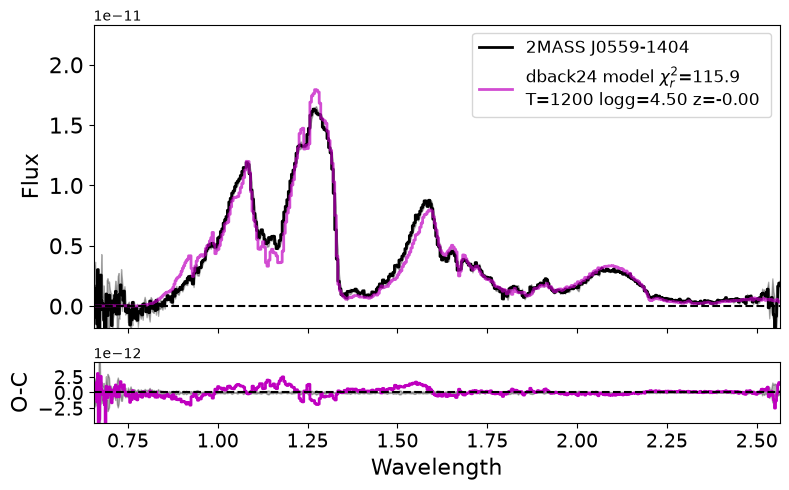

100%|██████████| 1000/1000 [00:03<00:00, 282.93it/s]


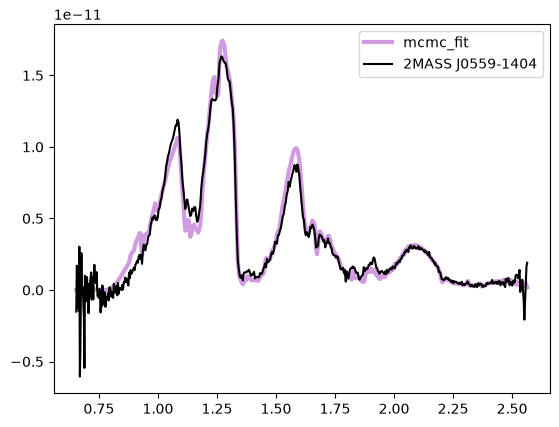

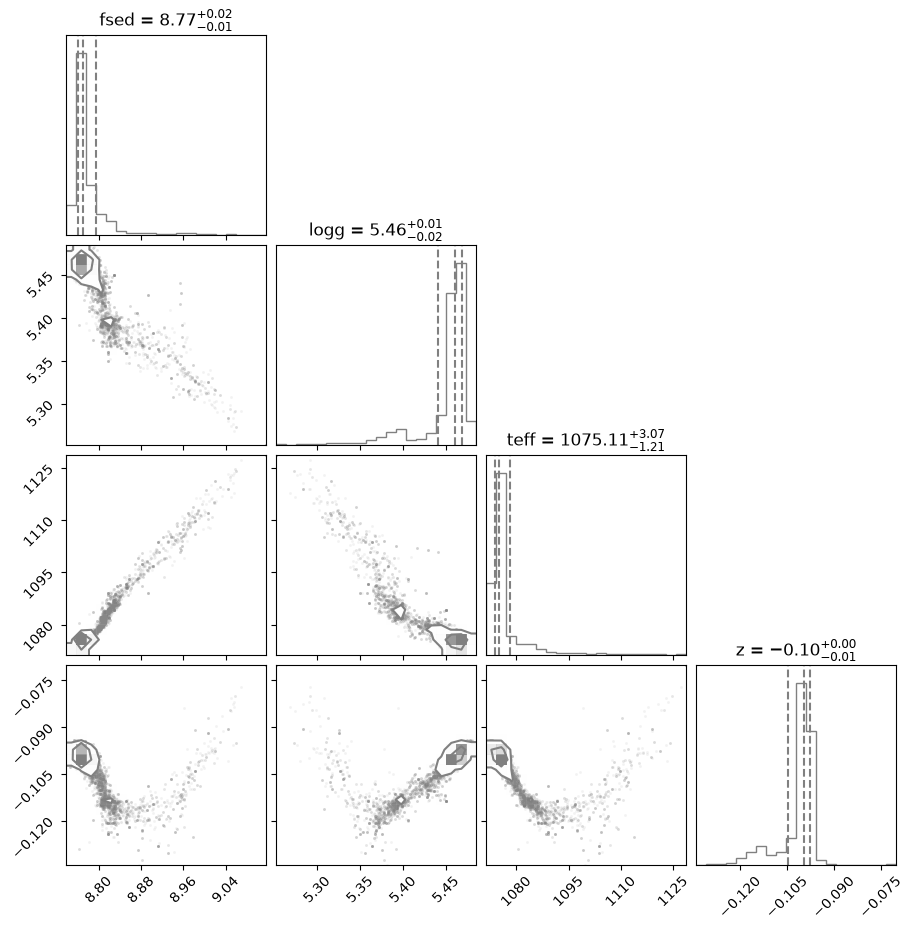

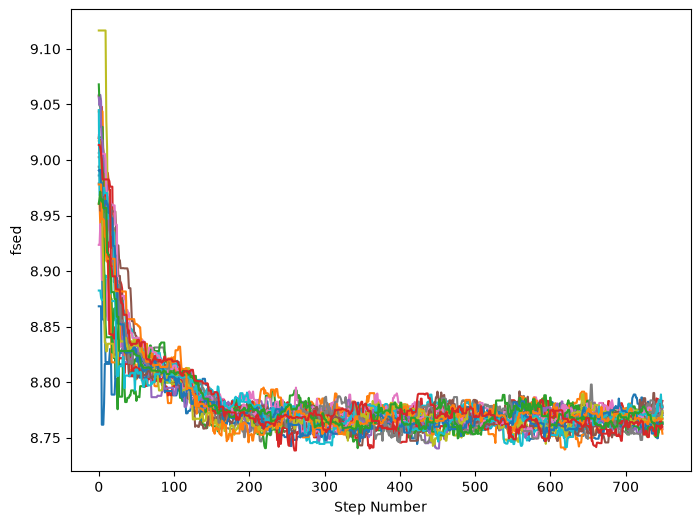

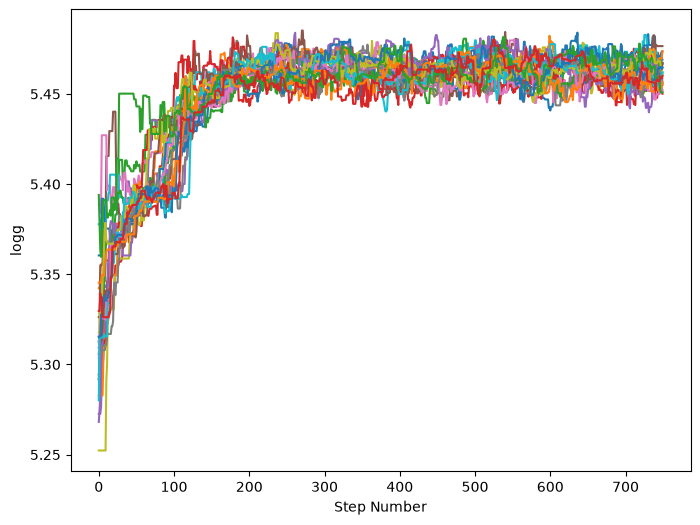

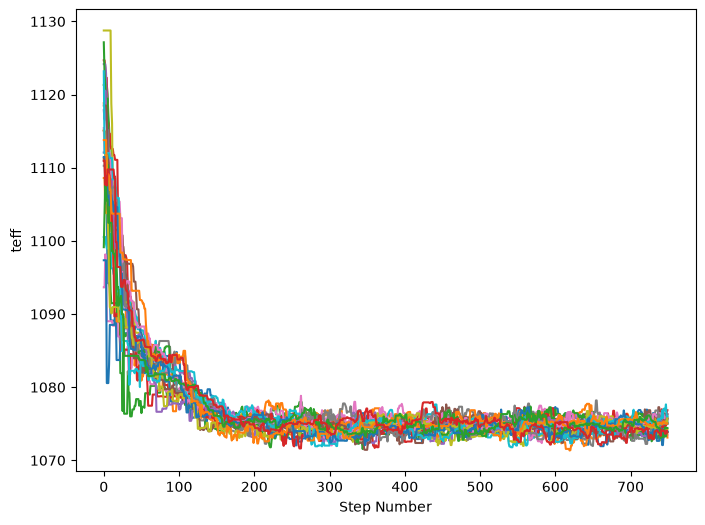

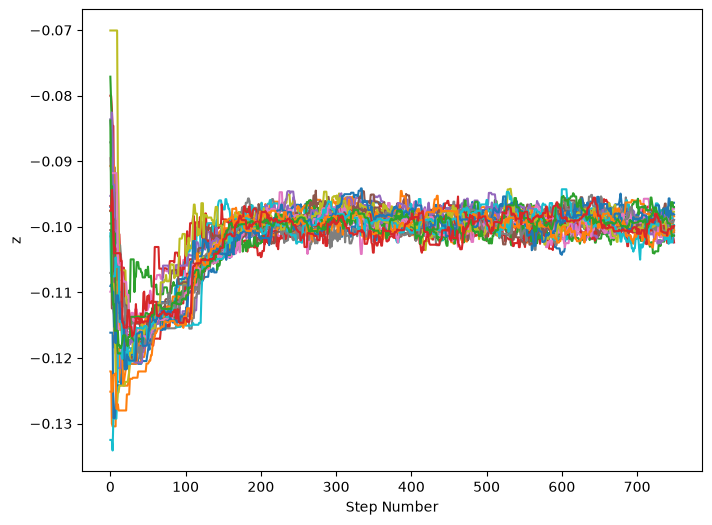

In [4]:
models, wave = ucdmcmc.getModelSet("dback24")
sp = ucdmcmc.getSample("SPEX-PRISM")

dback24_emcee = fitEMCEE(sp, models, NSTEPS=1000)

For my testing, I grabbed a bunch of different modelsets (see below) and would uncomment one when I wanted to test it. You can try it below or look thru ucdmcmc and find one I dont have listed below (it would be a huge help if you do btw and find any bugs for me to look into).

In [ ]:
# Model with NO discrete columns
# =================================
# models, wave = ucdmcmc.getModelSet("dback24")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sphinx23")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sonora21")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("newera25")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("lowz")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 1 discrete column (3 discrete values)
# =================================
# models, wave = ucdmcmc.getModelSet("lacy23")
# sp = ucdmcmc.getSample("SPEX-PRISM")

models, wave = ucdmcmc.getModelSet("exorem21")
sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 2 discrete columns (2 discrete values each)
# =================================
# models, wave = ucdmcmc.getModelSet("atmo20")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# FINAL BOSS OF TESTS:
# models, wave = ucdmcmc.getModelSet("sphinx25") # key error in fitmcmc
# sp = ucdmcmc.getSample("SPEX-PRISM")


models, wave = ucdmcmc.getModelSet("dback24")
sp = ucdmcmc.getSample("SPEX-PRISM")

glorp_ensembler = fitEMCEE(sp, models, NSTEPS=1000)